# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use('ggplot')
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# First Look

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Information

In [4]:
print("Dataset Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

Dataset Shape : (891, 12)

Columns
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Check Missing Values

In [5]:
missing = pd.DataFrame({
    'Missing Values':df.isnull().sum(),
    'Percentage':(df.isnull().sum()/len(df))*100
})

missing.sort_values(by='Percentage',ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


# Duplicate Values

In [7]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


# Categorical Statistics

In [8]:
df.describe(include='object').T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


# Data Cleaning

In [12]:
df['Age'].fillna(df['Age'].median(),inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Univariate Analysis  - Numerical Distribution

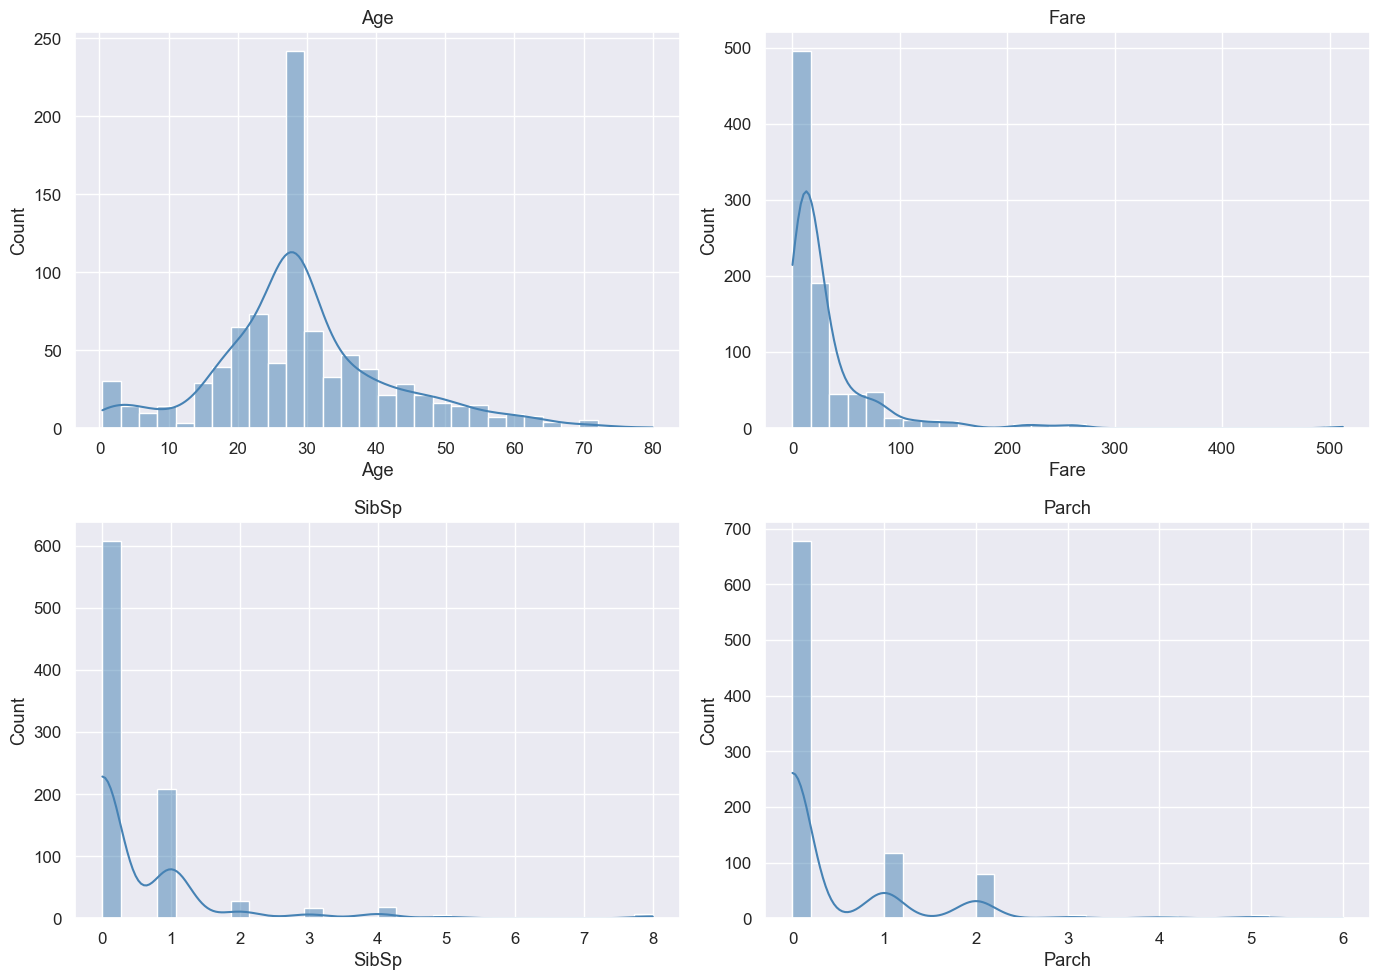

In [13]:
num_cols=['Age','Fare','SibSp','Parch']

plt.figure(figsize=(14,10))

for i,col in enumerate(num_cols):
    
    plt.subplot(2,2,i+1)
    sns.histplot(df[col],kde=True,bins=30,color='steelblue')
    plt.title(col)

plt.tight_layout()
plt.show()

# Boxplots

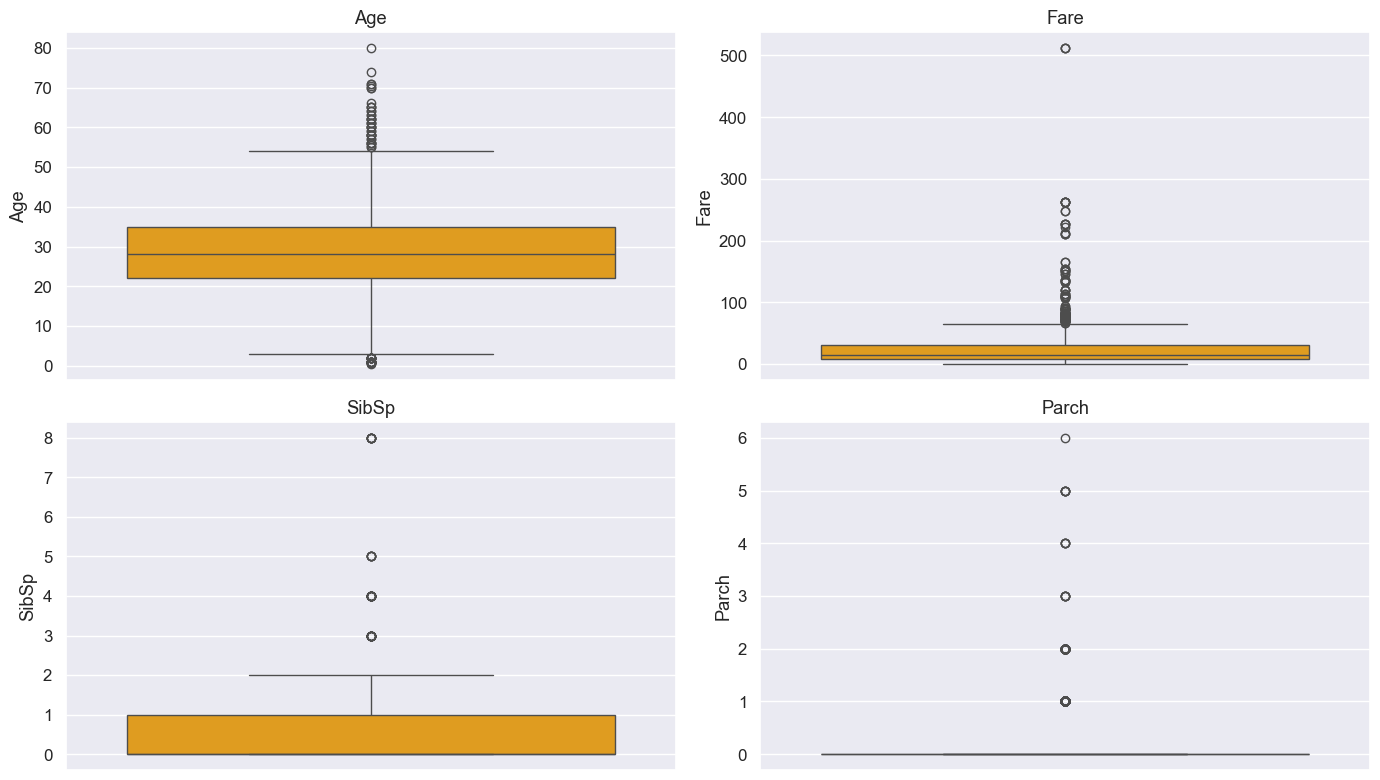

In [14]:
plt.figure(figsize=(14,8))

for i,col in enumerate(num_cols):

    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col],color='orange')
    plt.title(col)

plt.tight_layout()
plt.show()

# Survival Count

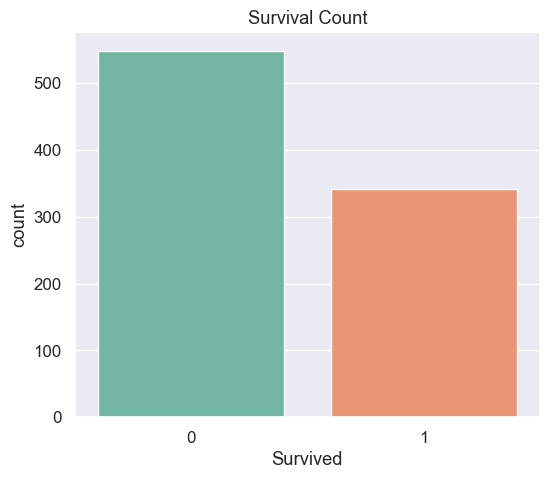

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(x='Survived',data=df,palette='Set2')

plt.title("Survival Count")

plt.show()


# Gender Distribution

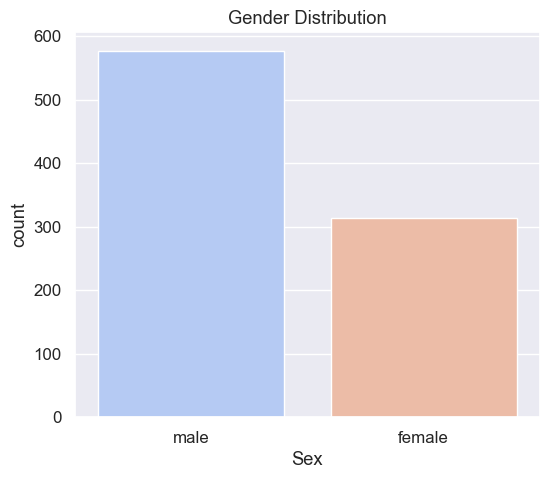

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x='Sex',data=df,palette='coolwarm')

plt.title("Gender Distribution")

plt.show()

# Passenger Class

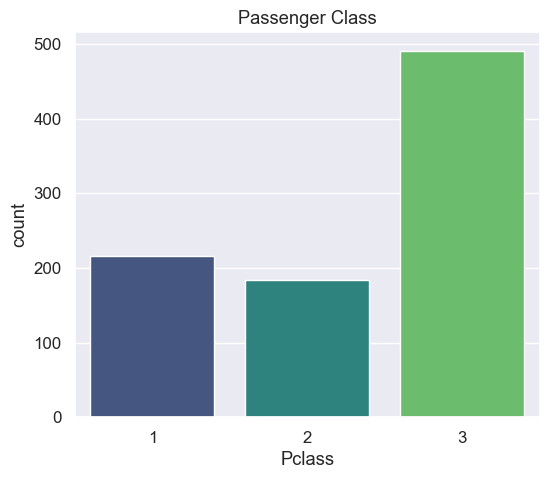

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(x='Pclass',data=df,palette='viridis')

plt.title("Passenger Class")

plt.show()

# Bivariate Analysis- Survival vs Gender

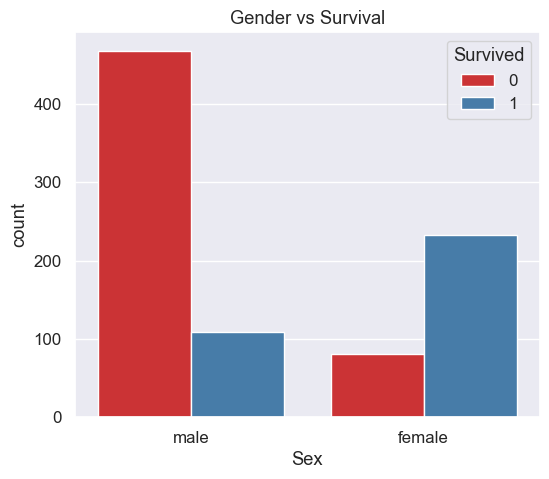

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(x='Sex',
              hue='Survived',
              data=df,
              palette='Set1')

plt.title("Gender vs Survival")

plt.show()

# Survival vs Passenger Class

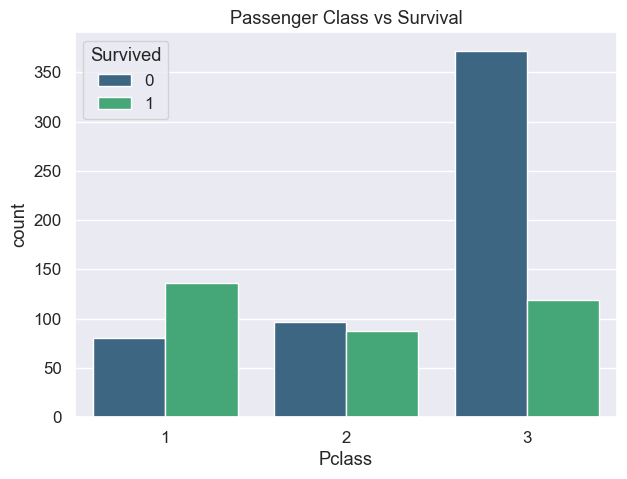

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x='Pclass',
              hue='Survived',
              data=df,
              palette='viridis')

plt.title("Passenger Class vs Survival")

plt.show()

# Age vs Survival

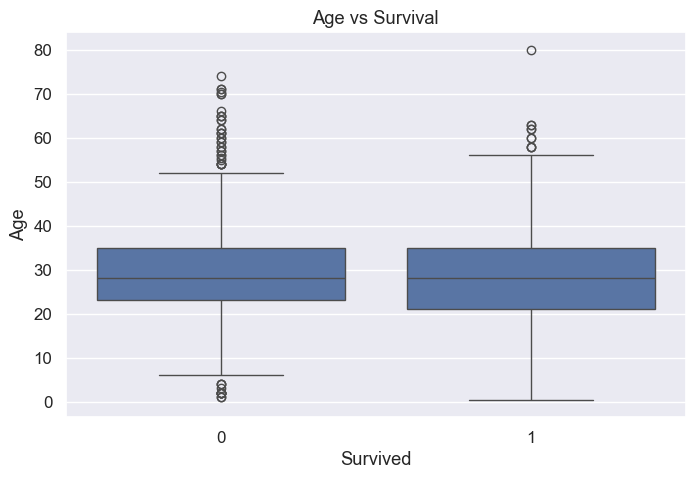

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Survived',
            y='Age',
            data=df)

plt.title("Age vs Survival")

plt.show()

# Fare vs Survival

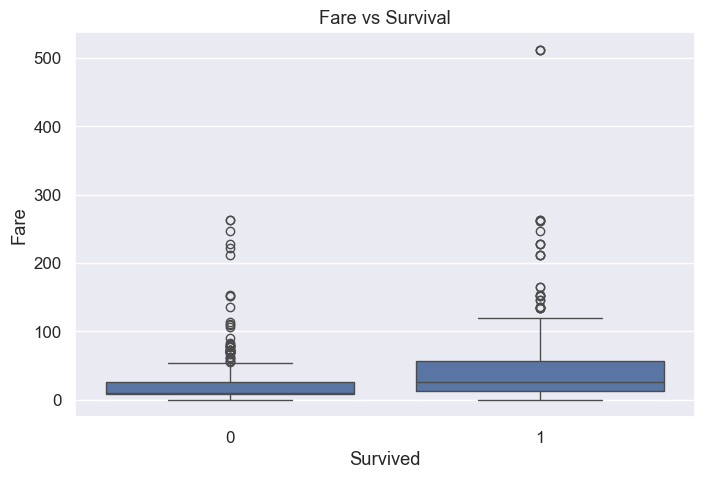

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Survived',
            y='Fare',
            data=df)

plt.title("Fare vs Survival")

plt.show()

# Correlation Matrix

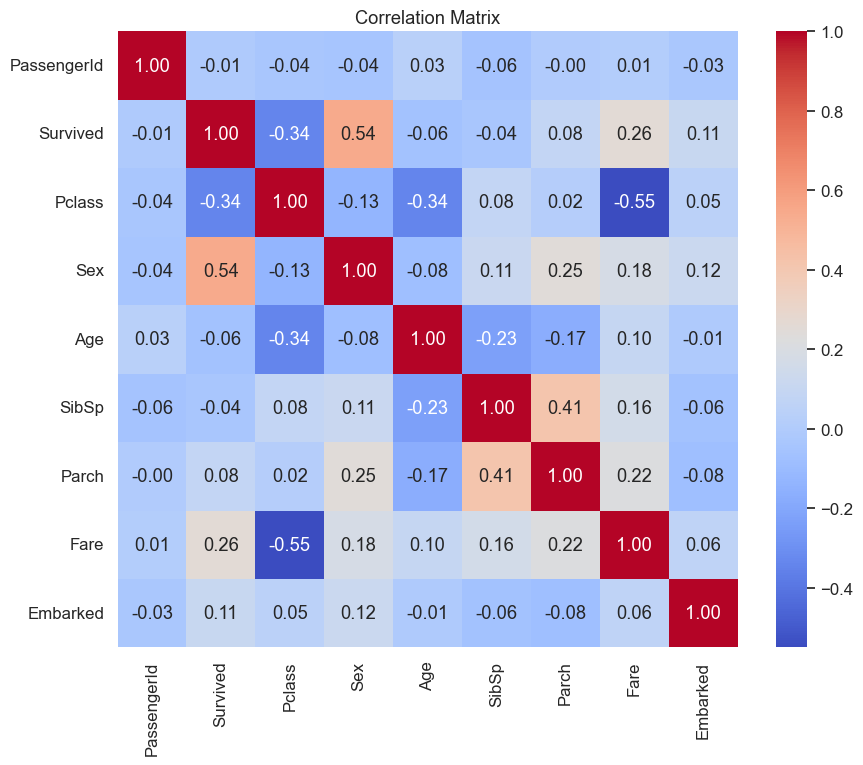

In [22]:
data=df.copy()

data['Sex']=data['Sex'].map({'male':0,'female':1})

data['Embarked']=data['Embarked'].map({'S':0,'C':1,'Q':2})

corr=data.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

# Plotly  Charts

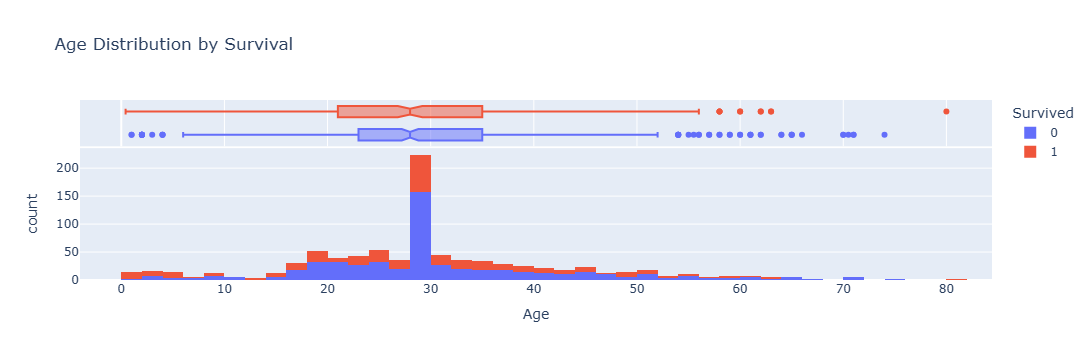

In [23]:
fig=px.histogram(df,
                 x='Age',
                 color='Survived',
                 marginal='box',
                 title='Age Distribution by Survival')

fig.show()

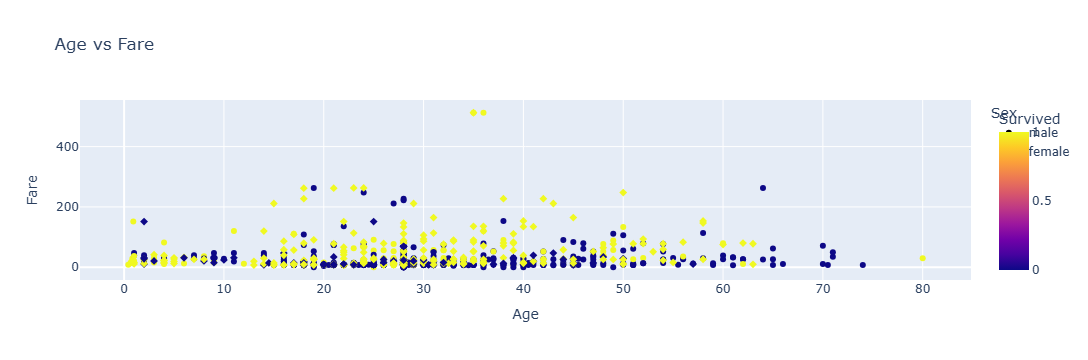

In [24]:
fig=px.scatter(df,
               x='Age',
               y='Fare',
               color='Survived',
               symbol='Sex',
               title='Age vs Fare')

fig.show()

# Outlier Detection

In [25]:
Q1=df['Fare'].quantile(0.25)

Q3=df['Fare'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df['Fare']<lower)|(df['Fare']>upper)]

print("Number of Fare Outliers :",len(outliers))

Number of Fare Outliers : 116


# Business Insights

In [26]:
print("EDA INSIGHTS")

print("-"*50)

print("1. Female passengers had a much higher survival rate.")

print("2. First-class passengers survived more frequently than lower classes.")

print("3. Fare is positively associated with survival probability.")

print("4. Age contains some missing values that were imputed using the median.")

print("5. Fare contains several high-value outliers.")

print("6. Most passengers embarked from Southampton.")

print("7. Most passengers traveled in Third Class.")

print("8. Family size may have influenced survival.")

print("9. Correlation analysis shows Passenger Class and Fare are important variables.")

print("10. The dataset is suitable for predictive machine learning after preprocessing.")

EDA INSIGHTS
--------------------------------------------------
1. Female passengers had a much higher survival rate.
2. First-class passengers survived more frequently than lower classes.
3. Fare is positively associated with survival probability.
4. Age contains some missing values that were imputed using the median.
5. Fare contains several high-value outliers.
6. Most passengers embarked from Southampton.
7. Most passengers traveled in Third Class.
8. Family size may have influenced survival.
9. Correlation analysis shows Passenger Class and Fare are important variables.
10. The dataset is suitable for predictive machine learning after preprocessing.
